# Rotating equipment and converter performance maps

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/energy_networks/02_rotating_equipment_and_converter_maps.ipynb)

This notebook demonstrates motor-driven equipment, shaft coupling, VFD/part-load motor performance, and load-dependent generator/transformer/prime-mover efficiency.

**Release requirement:** NeqSim 3.17.0 or later.\n\n**Implementation history:** PRs #2608, #2609, and #2615.
**Validated environment:** stored outputs use NeqSim 3.17.0, Python 3.12.13, and OpenJDK 17.0.19.


## 1. Setup

In [1]:
import importlib.metadata
import importlib.util
import subprocess
import sys

if (
    importlib.util.find_spec("google") is not None
    and importlib.util.find_spec("google.colab") is not None
):
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim==3.17.0",
        ],
        check=True,
    )

from neqsim import jneqsim
from jpype import JClass

neqsim_version = importlib.metadata.version("neqsim")
if neqsim_version != "3.17.0":
    raise RuntimeError(
        "This stored-output example was validated with NeqSim 3.17.0; " f"found {neqsim_version}."
    )
print(f"NeqSim {neqsim_version} loaded from the public Python package")


NeqSim 3.17.0 loaded from the public Python package


In [2]:
ElectricMotor = jneqsim.process.equipment.energy.ElectricMotor
Generator = jneqsim.process.equipment.energy.Generator
Transformer = jneqsim.process.equipment.energy.Transformer
PrimeMover = jneqsim.process.equipment.energy.PrimeMover
LoadEfficiencyCurve = jneqsim.process.equipment.energy.LoadEfficiencyCurve
ElectricMotorDriver = jneqsim.process.equipment.compressor.driver.ElectricMotorDriver
MechanicalShaft = jneqsim.process.equipment.stream.MechanicalShaft
EnergyBus = jneqsim.process.equipment.stream.EnergyBus
EnergyType = jneqsim.process.equipment.stream.EnergyType
EnergyPortMode = jneqsim.process.equipment.stream.EnergyPortMode
EnergyConverter = jneqsim.process.equipment.energy.EnergyConverter


## 2. Motor part-load and VFD capability

In [3]:
motor_driver = ElectricMotorDriver(5000.0, 3000.0, 0.96)
motor_driver.setMinSpeedRatio(0.3)
motor_driver.setMaxSpeedRatio(1.2)
motor_driver.setHasVFD(True)

motor = ElectricMotor("5 MW compressor motor")
motor.setPerformanceModel(motor_driver)

shaft = MechanicalShaft("compressor shaft")
shaft.setSpeed(2400.0)
motor.connectEnergyStream(EnergyConverter.OUTPUT_PORT, shaft, EnergyPortMode.CALCULATED)

loads = [0.1, 0.25, 0.5, 0.75, 1.0]
motor_rows = []
available = motor.getAvailableShaftPower()
for fraction in loads:
    output = fraction * available
    eta = motor.getEfficiencyAtOutputPower(output)
    input_power = motor.getRequiredInputPowerForOutput(output)
    motor_rows.append(
        {
            "load_fraction": fraction,
            "shaft_MW": output / 1e6,
            "electrical_MW": input_power / 1e6,
            "efficiency": eta,
        }
    )


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

motor_df = pd.DataFrame(motor_rows)
motor_df


Out[4]: 
   load_fraction  shaft_MW  electrical_MW  efficiency
0           0.10       0.4       1.263392    0.316608
1           0.25       1.0       1.263392    0.791520
2           0.50       2.0       2.260807    0.884640
3           0.75       3.0       3.287397    0.912576
4           1.00       4.0       4.295533    0.931200


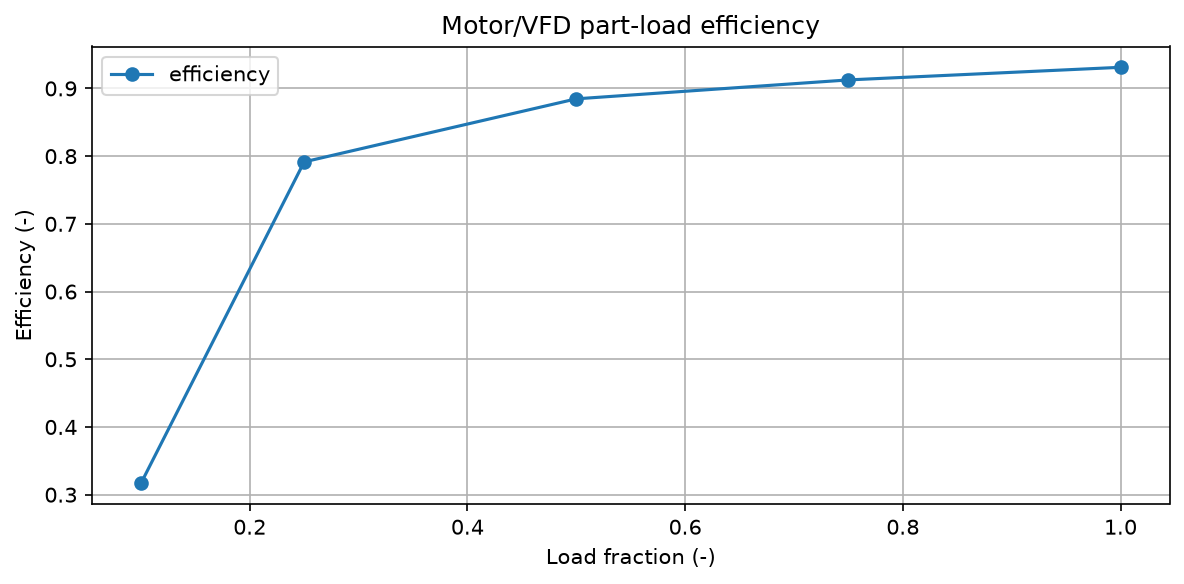

In [5]:
ax = motor_df.plot(x="load_fraction", y="efficiency", marker="o", figsize=(8, 4))
ax.set_xlabel("Load fraction (-)")
ax.set_ylabel("Efficiency (-)")
ax.set_title("Motor/VFD part-load efficiency")
ax.grid()
plt.tight_layout()
plt.show()


**Interpretation.** Fixed losses reduce efficiency at low load. A motor that is oversized for normal operation can consume materially more electricity than a constant-efficiency model predicts.

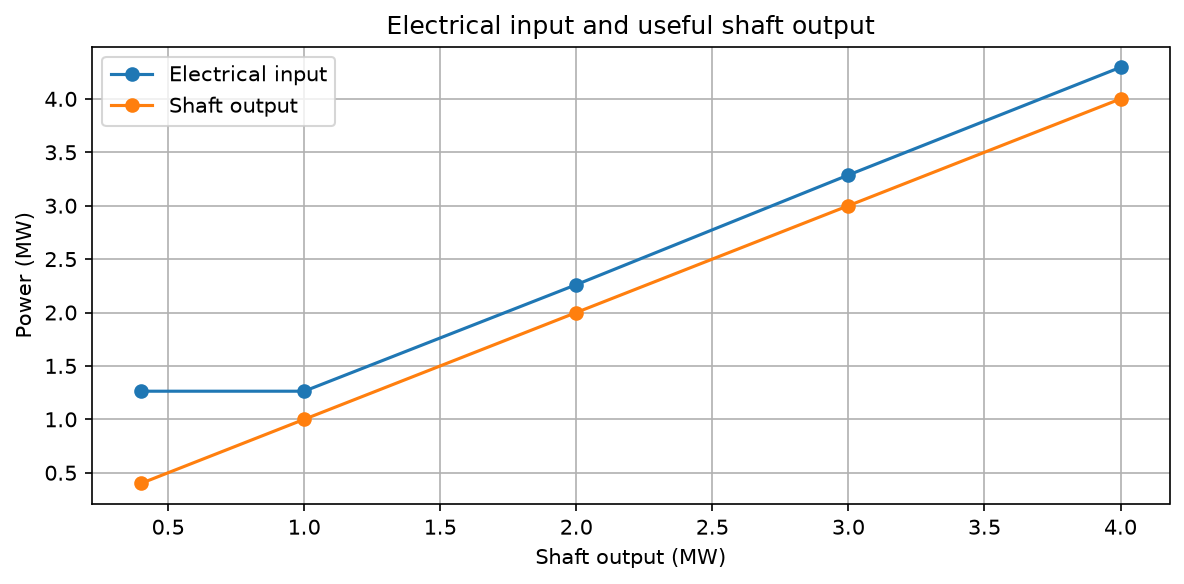

In [6]:
ax = motor_df.plot(
    x="shaft_MW", y="electrical_MW", marker="o", figsize=(8, 4), label="Electrical input"
)
ax.plot(motor_df["shaft_MW"], motor_df["shaft_MW"], marker="o", label="Shaft output")
ax.set_xlabel("Shaft output (MW)")
ax.set_ylabel("Power (MW)")
ax.set_title("Electrical input and useful shaft output")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()


**Interpretation.** The difference between electrical input and shaft output is conversion loss. Energy conservation is maintained at every operating point.

## 3. Generator and prime-mover efficiency curves

In [7]:
curve = LoadEfficiencyCurve([0.1, 0.25, 0.5, 0.75, 1.0], [0.70, 0.88, 0.94, 0.965, 0.97])

generator = Generator("main generator")
generator.setRatedOutputPower(10.0e6)
generator.setLoadEfficiencyCurve(curve)

prime = PrimeMover("gas turbine")
prime.setRatedOutputPower(12.0e6)
prime.setLoadEfficiencyCurve(
    LoadEfficiencyCurve([0.1, 0.25, 0.5, 0.75, 1.0], [0.15, 0.25, 0.32, 0.36, 0.38])
)

mapped = []
for fraction in [0.1, 0.25, 0.5, 0.75, 1.0]:
    gen_output = fraction * 10.0e6
    gt_output = fraction * 12.0e6
    mapped.append(
        {
            "load_fraction": fraction,
            "generator_efficiency": curve.getEfficiency(fraction),
            "prime_mover_efficiency": prime.getLoadEfficiencyCurve().getEfficiency(fraction),
            "generator_input_MW": generator.getRequiredInputPowerForOutput(gen_output) / 1e6,
            "fuel_input_MW": prime.getRequiredInputPowerForOutput(gt_output) / 1e6,
        }
    )
mapped_df = pd.DataFrame(mapped)
mapped_df


Out[7]: 
   load_fraction  generator_efficiency  ...  generator_input_MW  fuel_input_MW
0           0.10                 0.700  ...            1.428571       8.000000
1           0.25                 0.880  ...            2.840909      12.000000
2           0.50                 0.940  ...            5.319149      18.750000
3           0.75                 0.965  ...            7.772021      25.000000
4           1.00                 0.970  ...           10.309278      31.578947

[5 rows x 5 columns]


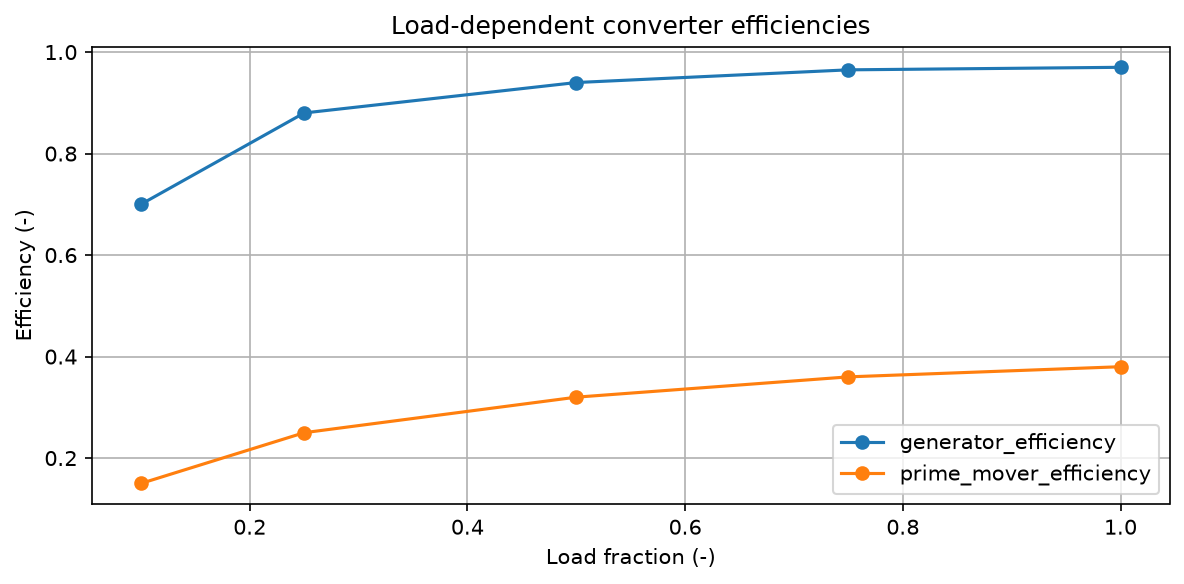

In [8]:
ax = mapped_df.plot(
    x="load_fraction",
    y=["generator_efficiency", "prime_mover_efficiency"],
    marker="o",
    figsize=(8, 4),
)
ax.set_xlabel("Load fraction (-)")
ax.set_ylabel("Efficiency (-)")
ax.set_title("Load-dependent converter efficiencies")
ax.grid()
plt.tight_layout()
plt.show()


**Interpretation.** Prime-mover efficiency typically changes more strongly with load than generator efficiency. This affects fuel use, emissions, and optimal train loading.

## Validation checks

The assertions below lock the engineering balances and benchmark values used in the interpretation.


In [9]:
assert motor_df["efficiency"].between(0.0, 1.0).all()
assert (motor_df["electrical_MW"] >= motor_df["shaft_MW"]).all()
assert motor_df["efficiency"].is_monotonic_increasing
assert mapped_df["generator_efficiency"].between(0.0, 1.0).all()
assert mapped_df["prime_mover_efficiency"].between(0.0, 1.0).all()
assert (mapped_df["generator_input_MW"] >= 10.0 * mapped_df["load_fraction"]).all()

validation = pd.Series(
    {
        "minimum motor efficiency (-)": motor_df["efficiency"].min(),
        "maximum motor efficiency (-)": motor_df["efficiency"].max(),
        "maximum generator efficiency (-)": mapped_df["generator_efficiency"].max(),
        "maximum prime-mover efficiency (-)": mapped_df["prime_mover_efficiency"].max(),
    }
)
validation


Out[9]: 
minimum motor efficiency (-)          0.316608
maximum motor efficiency (-)          0.931200
maximum generator efficiency (-)      0.970000
maximum prime-mover efficiency (-)    0.380000
dtype: float64


## Summary

Use detailed performance maps for concept selection, electrification studies, compressor-driver matching, and operating optimization. Retain constant-efficiency models for early screening when detailed data are unavailable.